# Raw data 정리

In [140]:
%pip install pandas
%pip install numpy

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [141]:
import pandas as pd
import numpy as np
import os
import glob
import re

# 1. get raw data files
# demand data => monthly data
df_demand = pd.read_csv('../data/demand.csv')
df_demand.rename(columns={'year_month': 'date', '총계': 'demand'}, inplace=True)
df_demand = df_demand[['date', 'demand']]
df_demand['date'] = pd.to_datetime(df_demand['date'], format='%Y%m')

# 🔹 여기서 문자열 → 숫자로 변환
df_demand["demand"] = (
    df_demand["demand"]
        .astype(str)                      # 혹시 모를 타입 섞임 방지
        .str.replace(",", "", regex=False)  # 천단위 콤마 제거
)
df_demand["demand"] = pd.to_numeric(df_demand["demand"], errors="coerce")

# weather data => daily data
df_weather = pd.read_csv('../data/korea_daily_avg_ta_rn_20010101_20250831.csv')
df_weather = df_weather[['date', 'ta_avg_mean','rn_day_mean']]

# get price data files and merge them => daily data
files = sorted(glob.glob(os.path.join("../data/price*.csv")))
dfs = []
for f in files:
    df = pd.read_csv(f)
    # 1) 날짜 컬럼만 골라내기 (예: '2001.1.2', '2010.12.21' 형태)
    date_pat = re.compile(r"^\d{4}\.\d{1,2}\.\d{1,2}$")
    date_cols = [c for c in df.columns if isinstance(c, str) and date_pat.match(c)]

    # (선택) 필요한 Quotation Source만 필터링 (두 개만 원할 때)
    need_sources = ["PLATT'S CRUDE", "PLATT'S AP/AG"]
    df = df[df["Quotation Source"].isin(need_sources)]

    # 2) wide → long
    long = df.melt(
        id_vars=["Quotation Source"],
        value_vars=date_cols,
        var_name="date",
        value_name="price"
    )

    # 3) 타입 정리
    long["date"] = pd.to_datetime(long["date"], format="%Y.%m.%d", errors="coerce")
    long["price"] = pd.to_numeric(long["price"], errors="coerce")

    # 4) long → wide (행=날짜, 열=Quotation Source)
    df_price_pivot = (
        long.pivot_table(index="date", columns="Quotation Source", values="price", aggfunc="first")
            .sort_index()
    )

    # (선택) 날짜가 모두 결측인 행 제거
    df_price_pivot = df_price_pivot.dropna(how="all")
    df.head()
    dfs.append(df_price_pivot)
df_price = pd.concat(dfs, ignore_index=False)

In [142]:
# df_price 결측치 보정 by linear interpolation
df_price = df_price.interpolate(method='linear')

In [143]:
# 결측치 확인
print(df_price.isnull().sum())
print(df_demand.isnull().sum())
print(df_weather.isnull().sum()) # 날씨 결측치는 강수량이 없다는 의미 -> 처리 필요 없음


Quotation Source
PLATT'S AP/AG    0
PLATT'S CRUDE    0
dtype: int64
date      0
demand    0
dtype: int64
date              0
ta_avg_mean       0
rn_day_mean    1846
dtype: int64


In [144]:
# 1) 월초('MS') 기준으로 리샘플링
df_price_monthly = df_price.sort_index().resample("MS").mean().reset_index()
df_price_monthly.rename(columns={"date": "date"}, inplace=True)

# 확인
print(df_price_monthly.head())
# date 가 2001-01-01, 2001-02-01 ... 처럼 나오면 OK

Quotation Source       date  PLATT'S AP/AG  PLATT'S CRUDE
0                2001-01-01     118.215909      22.850909
1                2001-02-01     130.668750      24.803000
2                2001-03-01     132.869318      23.449545
3                2001-04-01     136.556250      24.183000
4                2001-05-01     145.747283      25.663043


In [145]:
df_price_weight = pd.merge(df_demand, df_price_monthly, on="date", how="left")
print(df_price_weight.head())
# date, demand, PLATT'S AP/AG, PLATT'S CRUDE 가 전부 숫자로 찍히는지 확인

        date  demand  PLATT'S AP/AG  PLATT'S CRUDE
0 2001-01-01   18786     118.215909      22.850909
1 2001-02-01   31063     130.668750      24.803000
2 2001-03-01   95192     132.869318      23.449545
3 2001-04-01  161437     136.556250      24.183000
4 2001-05-01  176527     145.747283      25.663043


In [146]:
ap_col    = "PLATT'S AP/AG"
crude_col = "PLATT'S CRUDE"

# 가격이 없는(완전 NaN) 달은 일단 제외하고 bin 계산
valid = df_price_weight.dropna(subset=[ap_col, crude_col]).copy()

# 10개 분위수 bin
valid["ap_bin"]    = pd.qcut(valid[ap_col],    q=10, duplicates="drop")
valid["crude_bin"] = pd.qcut(valid[crude_col], q=10, duplicates="drop")

# 각 bin 별 평균 수요량
ap_bin_mean    = valid.groupby("ap_bin")["demand"].mean()
crude_bin_mean = valid.groupby("crude_bin")["demand"].mean()

# bin → 평균 수요량 매핑
valid["ap_price_weight"]    = valid["ap_bin"].map(ap_bin_mean)
valid["crude_price_weight"] = valid["crude_bin"].map(crude_bin_mean)

# 원래 df에 다시 붙이기
df_price_weight = df_price_weight.merge(
    valid[["date", "ap_price_weight", "crude_price_weight"]],
    on="date",
    how="left",
)

df_price_weight.head()

/var/folders/3t/x_vcdczj5fn_v1nnkppzjpwh0000gn/T/ipykernel_3498/3866290323.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ap_bin_mean    = valid.groupby("ap_bin")["demand"].mean()
/var/folders/3t/x_vcdczj5fn_v1nnkppzjpwh0000gn/T/ipykernel_3498/3866290323.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  crude_bin_mean = valid.groupby("crude_bin")["demand"].mean()


,date,demand,PLATT'S AP/AG,PLATT'S CRUDE,ap_price_weight,crude_price_weight
0,2001-01-01,18786,118.215909,22.850909,146683.833333,144764.166667
1,2001-02-01,31063,130.668750,24.803000,146683.833333,144764.166667
2,2001-03-01,95192,132.869318,23.449545,146683.833333,144764.166667
3,2001-04-01,161437,136.556250,24.183000,146683.833333,144764.166667
4,2001-05-01,176527,145.747283,25.663043,146683.833333,144764.166667


# feature 생성
이제 아래에 위 raw data들 가지고 각자 feature 생성해주면 됩니다~ 
최종 dataframe은 df 로 모든 feature를 넣을 예정!

In [147]:
# season feature
# df = df_demand
# df['season'] = df['date'].dt.month % 12 // 3 # winter: 0, spring: 1, summer: 2, autumn: 3

In [148]:
# season feature
df = df_demand
df['season_sin'] = np.sin(2 * np.pi * df['date'].dt.month / 12)
df['season_cos'] = np.cos(2 * np.pi * df['date'].dt.month / 12)

In [149]:
# 월별 평균 가격 df (monthly_price_df)
monthly_price_df = (
    df_price.resample("M").mean()
             .reset_index()
)
monthly_price_df["date"] = monthly_price_df["date"].dt.strftime("%Y%m")
monthly_price_df.head()


/var/folders/3t/x_vcdczj5fn_v1nnkppzjpwh0000gn/T/ipykernel_3498/2380502797.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_price.resample("M").mean()


Quotation Source,date,PLATT'S AP/AG,PLATT'S CRUDE
0,200101,118.215909,22.850909
1,200102,130.668750,24.803000
2,200103,132.869318,23.449545
3,200104,136.556250,24.183000
4,200105,145.747283,25.663043


In [150]:
# 월별 가격 변동률 df (mom_pct_df)
price_cols = ["PLATT'S AP/AG", "PLATT'S CRUDE"]
monthly_price_df[price_cols] = monthly_price_df[price_cols].apply(pd.to_numeric)

mom_pct_df = monthly_price_df[price_cols].pct_change().shift(-1) * 100
mom_pct_df.index = monthly_price_df["date"]
mom_pct_df.head()

Quotation Source,PLATT'S AP/AG,PLATT'S CRUDE
date,,
200101,10.533981,8.542728
200102,1.684081,-5.456818
200103,2.774856,3.127799
200104,6.730584,6.120181
200105,-8.693062,-0.035054


In [151]:
# monthly_weight_df (수요량에 따른 월별 가중치)

demand = (
    pd.read_csv("../data/demand.csv", encoding="utf-8-sig")
      .drop(columns=[""], errors="ignore")
)

# clean values and split year/month
demand["총계"] = demand["총계"].str.replace(",", "", regex=False).astype(float)
demand["year_month"] = demand["year_month"].astype(str).str.zfill(6)
demand["year"] = demand["year_month"].str[:4].astype(int)
demand["month"] = demand["year_month"].str[4:].astype(int)


# share of each month within its year
demand["year_total"] = demand.groupby("year")["총계"].transform("sum")
demand["month_weight"] = demand["총계"] / demand["year_total"]

# average January weight, average February weight, … average December weight
monthly_weights = (
    demand.groupby("month")["month_weight"]
          .mean()
          .rename("avg_weight")
          .reindex(range(1, 13))
          .reset_index()
)

monthly_weights["month"] = monthly_weights["month"].astype(str).str.zfill(2)
monthly_weights["avg_weight"] = monthly_weights["avg_weight"].round(4)

monthly_weights



,month,avg_weight
0,01,0.0340
1,02,0.0359
2,03,0.0679
3,04,0.0913
4,05,0.1065
5,06,0.1117
6,07,0.0767
7,08,0.0765
8,09,0.0937
9,10,0.0981


In [152]:
# === 1. 날씨 기반 Feature 생성 ===

# (1) 컬럼명 표준화
df_weather.rename(columns={'ta_avg_mean': 'temp_avg', 'rn_day_mean': 'precip_total'}, inplace=True)
df_weather['date'] = pd.to_datetime(df_weather['date'], errors='coerce')

# (2) 데이터 타입 변환 (비교 오류 방지)
df_weather['temp_avg'] = pd.to_numeric(df_weather['temp_avg'], errors='coerce')
df_weather['precip_total'] = pd.to_numeric(df_weather['precip_total'], errors='coerce')

# (3) 임계값 정의
TEMP_THRESHOLD = -5   # 영하 5도 이하 → 시공 불가
RAIN_THRESHOLD = 30   # 강수량 30mm 초과 → 시공 불가

# (4) 일별 기준 불가능 조건 플래그
df_weather['month'] = df_weather['date'].dt.to_period('M')
df_weather['threshold_temp'] = (df_weather['temp_avg'] < TEMP_THRESHOLD).astype(int)
df_weather['threshold_rain'] = (df_weather['precip_total'] > RAIN_THRESHOLD).astype(int)
df_weather['is_weekend'] = (df_weather['date'].dt.weekday >=5).astype(int)

# (5) 월별 집계
df_weather_features = (
    df_weather.groupby('month')
    .agg(
        temp_avg=('temp_avg', 'mean'),
        precip_avg=('precip_total', 'mean'),
        threshold_temp_days=('threshold_temp', 'sum'),
        threshold_rainy_days=('threshold_rain', 'sum'),
        weekend_days=('is_weekend', 'sum'),
        days_in_month=('date', 'count')
    )
    .reset_index()
)

# (6) 공사 불가능/가능 일수 계산
df_weather_features['unworkable_days'] = (
    df_weather_features['threshold_temp_days'] + df_weather_features['threshold_rainy_days']
)
df_weather_features['possible_working_days'] = (
    df_weather_features['days_in_month'] - df_weather_features['unworkable_days'] - df_weather_features['weekend_days']
)

# (7) 날짜 포맷 통일
df_weather_features['date'] = df_weather_features['month'].astype(str)
df_weather_features['date'] = pd.to_datetime(df_weather_features['date'])
df_weather_features = df_weather_features[
    ['date', 'temp_avg', 'precip_avg', 'threshold_temp_days',
     'threshold_rainy_days', 'possible_working_days']
]

# 확인용 출력
print("날씨 기반 feature 생성 완료:", df_weather_features.shape)
print(df_weather_features.head())


날씨 기반 feature 생성 완료: (296, 6)
        date   temp_avg  precip_avg  threshold_temp_days  \
0 2001-01-01  -2.617516    2.119862                    8   
1 2001-02-01   0.583643    3.207810                    0   
2 2001-03-01   5.205774    0.903880                    0   
3 2001-04-01  12.494833    2.184500                    0   
4 2001-05-01  18.081581    2.028333                    0   

   threshold_rainy_days  possible_working_days  
0                     0                     15  
1                     0                     20  
2                     0                     22  
3                     0                     21  
4                     0                     23  


In [153]:
# === 1. 날짜 컬럼 정규화 ===
# mom_pct_df는 인덱스 또는 문자열 형태의 '200101' 형식이므로 datetime으로 변환
if 'date' not in mom_pct_df.columns:
    mom_pct_df = mom_pct_df.reset_index().rename(columns={'index': 'date'})
else:
    mom_pct_df = mom_pct_df.copy()

mom_pct_df['date'] = pd.to_datetime(
    mom_pct_df['date'].astype(str).str.replace(r'\D', '', regex=True),
    format='%Y%m',
    errors='coerce'
)

# monthly_weights는 month만 있으므로, 정수형으로 변환
monthly_weights['month'] = monthly_weights['month'].astype(int)

# === 2. 기본 demand + season ===
final_df = df.copy()

# demand 컬럼 내 콤마 제거 후 숫자형 변환
final_df['demand'] = (
    final_df['demand']
    .astype(str)
    .str.replace(',', '', regex=False)
    .astype(float)
)

# === 3. mom_pct_df 병합 ===
final_df = final_df.merge(mom_pct_df, on='date', how='left')

# === 4. weather_features 병합 ===
final_df = final_df.merge(df_weather_features, on='date', how='left')

# === 5. month_weight 병합 ===
final_df['month'] = final_df['date'].dt.month
final_df = final_df.merge(monthly_weights, on='month', how='left')

# === 5-1. df_price_weight 병합 (ap_price_weight, crude_price_weight) ===
# final_df의 date는 datetime 형식이므로, df_price_weight의 date도 datetime 형식으로 유지하여 병합
# ap_price_weight, crude_price_weight 컬럼만 선택하여 병합
price_weight_cols = df_price_weight[['date', 'ap_price_weight', 'crude_price_weight']]
final_df = final_df.merge(price_weight_cols, on='date', how='left')

# === 6. 컬럼 정리 및 형식 통일 ===
# 가격 변동률 컬럼명 변경
final_df = final_df.rename(columns={
    "PLATT'S AP/AG": "platt_apag_mom_pct",
    "PLATT'S CRUDE": "platt_crude_mom_pct"
})

# date를 'YYYYMM' 문자열 형식으로 변환 (예: 200101)
final_df['date'] = final_df['date'].dt.strftime('%Y%m')

# 불필요 컬럼 제거 및 정렬
final_df = final_df.drop(columns=['month'], errors='ignore')
final_df = final_df.sort_values('date').reset_index(drop=True)
final_df = final_df.dropna()

print("통합 Feature DataFrame 크기:", final_df.shape)
print(final_df.head(10))

# 불필요한 칼럼 제거
final_df = final_df.drop(columns=['platt_apag_mom_pct', 'platt_crude_mom_pct', 'threshold_rainy_days', 'threshold_temp_days'], errors='ignore')

# === 7. CSV 저장 ===
output_path = "../data/final_features_3.csv"
final_df.to_csv(output_path, index=False, encoding="utf-8-sig")

print("최종 feature 파일 CSV 저장 완료:", output_path)

통합 Feature DataFrame 크기: (296, 14)
     date    demand    season_sin    season_cos  platt_apag_mom_pct  \
0  200101   18786.0  5.000000e-01  8.660254e-01           10.533981   
1  200102   31063.0  8.660254e-01  5.000000e-01            1.684081   
2  200103   95192.0  1.000000e+00  6.123234e-17            2.774856   
3  200104  161437.0  8.660254e-01 -5.000000e-01            6.730584   
4  200105  176527.0  5.000000e-01 -8.660254e-01           -8.693062   
5  200106  174338.0  1.224647e-16 -1.000000e+00           -3.879403   
6  200107  131949.0 -5.000000e-01 -8.660254e-01            8.128637   
7  200108  174500.0 -8.660254e-01 -5.000000e-01            4.401265   
8  200109  213406.0 -1.000000e+00 -1.836970e-16          -14.150006   
9  200110  162373.0 -8.660254e-01  5.000000e-01          -16.462178   

   platt_crude_mom_pct   temp_avg  precip_avg  threshold_temp_days  \
0             8.542728  -2.617516    2.119862                  8.0   
1            -5.456818   0.583643    3.2078

In [154]:

# final_df 칼럼 출력
print(final_df.columns)



Index(['date', 'demand', 'season_sin', 'season_cos', 'temp_avg', 'precip_avg',
       'possible_working_days', 'avg_weight', 'ap_price_weight',
       'crude_price_weight'],
      dtype='object')


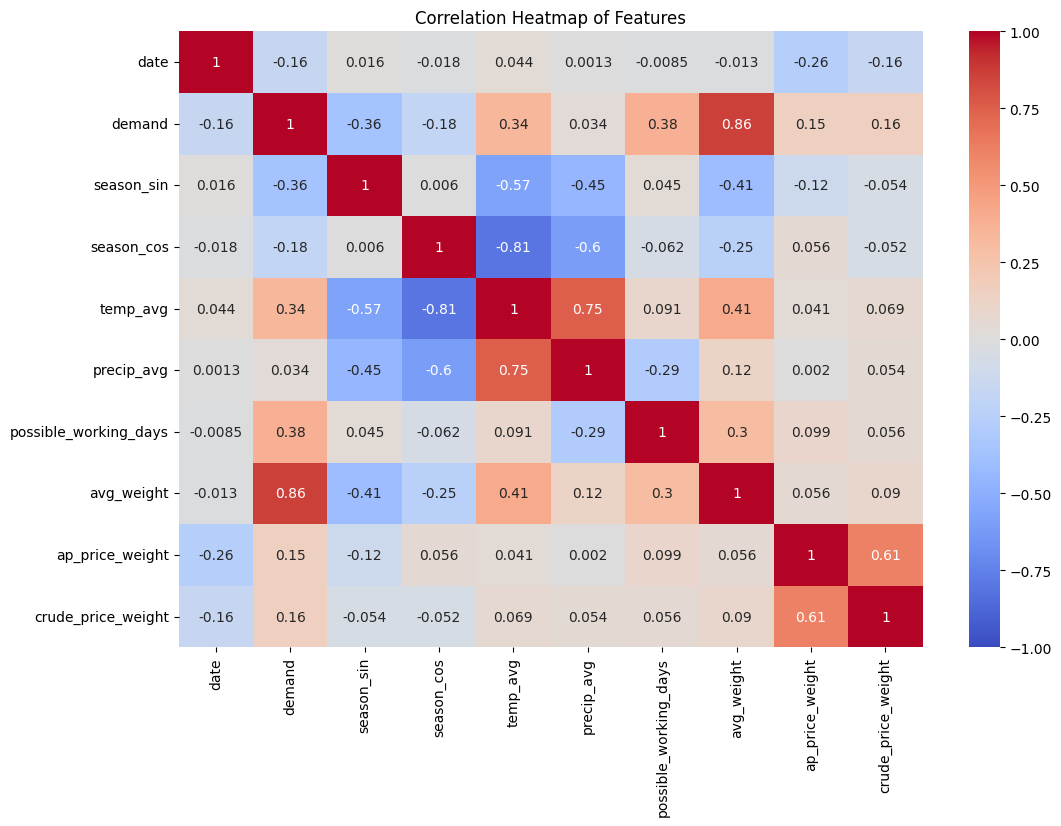

In [155]:
import matplotlib.pyplot as plt
import seaborn as sns

feature_df = final_df

# 상관 관계 확인
correlation_matrix = feature_df.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Features')
plt.show()
